# Project 1 — Customer Churn Prediction | Version 1

Dataset: **Kaggle Telco Customer Churn**  
Nguồn tải: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Version 1 làm trong notebook, **chưa deployment**:

1. EDA  
2. Missing values  
3. Encoding categorical  
4. Feature engineering  
5. Train Logistic Regression  
6. Train Random Forest  
7. Hyperparameter tuning  
8. Save model bằng `joblib`

Sau khi tải dataset, đặt file CSV vào một trong hai vị trí:

```text
data/WA_Fn-UseC_-Telco-Customer-Churn.csv
WA_Fn-UseC_-Telco-Customer-Churn.csv
```

## 0. Import libraries

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
TARGET = "Churn"
sns.set_theme(style="whitegrid")

## 1. Load dataset

In [ ]:
# Thư mục gốc của project (parent của mini_projects/)
BASE_DIR = Path.cwd().parent 

# Đường dẫn cụ thể tới file CSV
DATA_PATH = BASE_DIR / "data" / "customers" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy dataset tại: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("Load dataset thành công!")
print("Path:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Load dataset thành công!
Path: c:\Users\ASUS\Documents\PROJECT\intro_to_AI\data\customers\WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data overview

Kiểm tra nhanh: shape, columns, data types, duplicated rows, target distribution.

In [12]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
print("Duplicated rows:", df.duplicated().sum())

if "customerID" in df.columns:
    print("Duplicated customerID:", df["customerID"].duplicated().sum())

print("\nTarget count:")
print(df[TARGET].value_counts())

print("\nTarget percentage:")
print(df[TARGET].value_counts(normalize=True).mul(100).round(2))

Duplicated rows: 0
Duplicated customerID: 0

Target count:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


## 3. EDA — Exploratory Data Analysis

Mục tiêu:

- Nhìn phân bố `Churn`
- Xem nhóm nào churn cao
- Quan sát numeric features như `tenure`, `MonthlyCharges`, `TotalCharges`

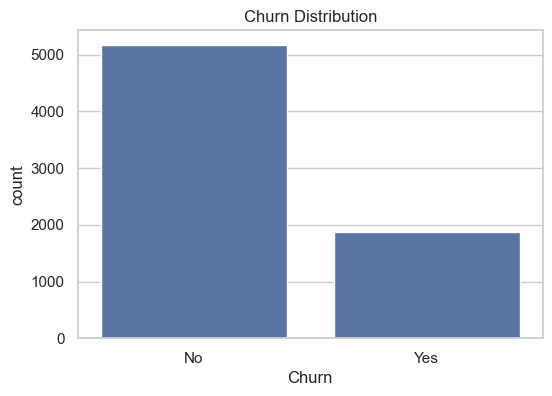

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET)
plt.title("Churn Distribution")
plt.show()

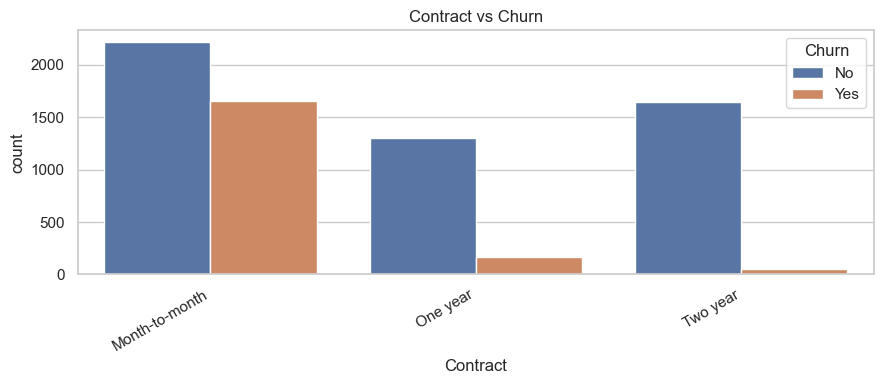

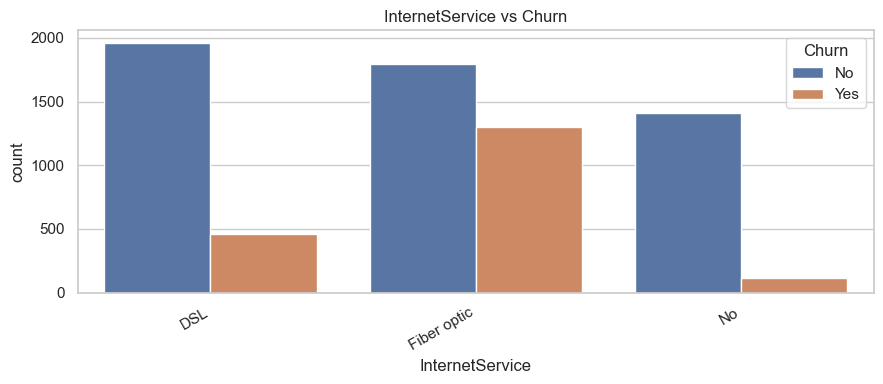

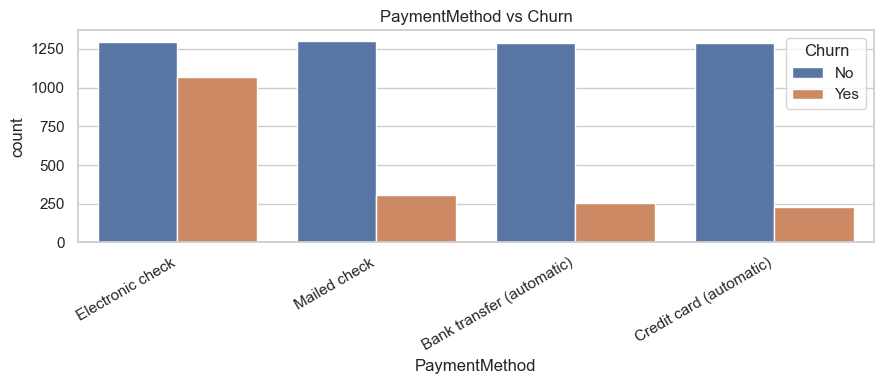

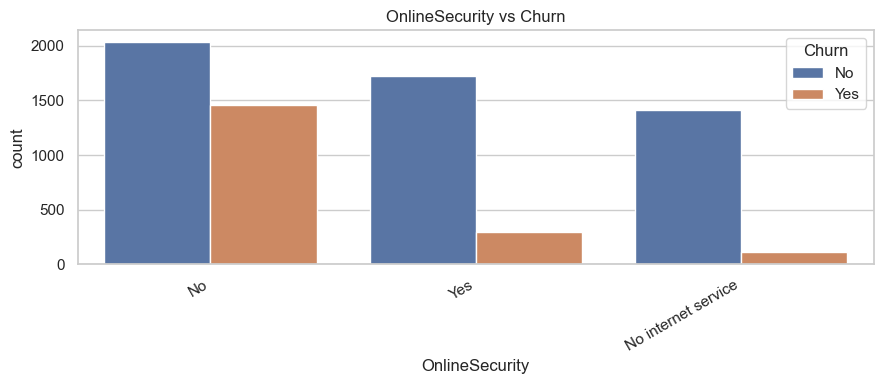

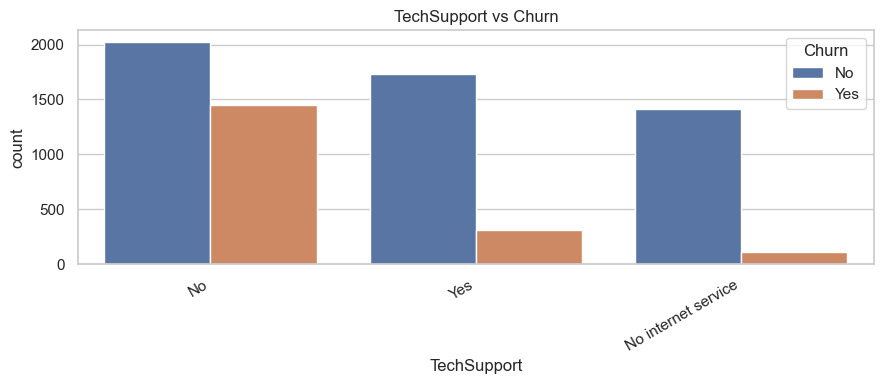

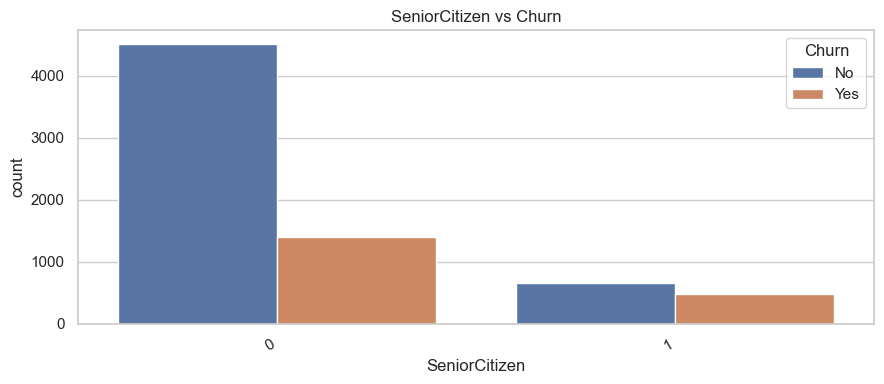

In [17]:
cat_cols_to_plot = [
    "Contract", "InternetService", "PaymentMethod",
    "OnlineSecurity", "TechSupport", "SeniorCitizen"
]

for col in cat_cols_to_plot:
    if col in df.columns:
        plt.figure(figsize=(9, 4))
        sns.countplot(data=df, x=col, hue=TARGET)
        plt.title(f"{col} vs Churn")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

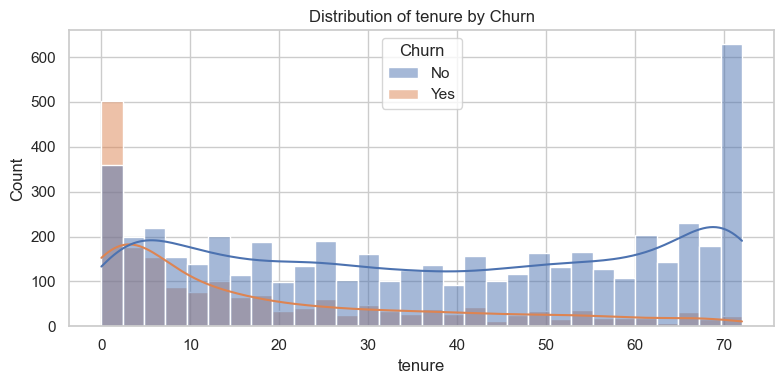

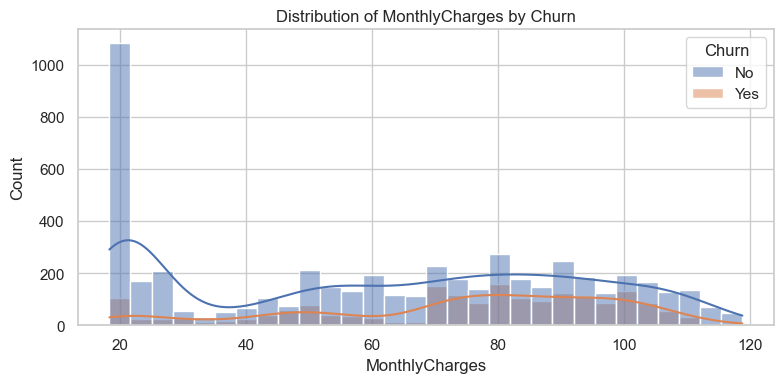

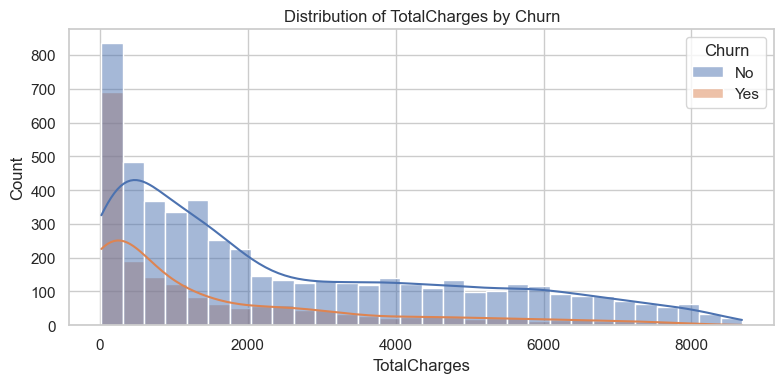

In [18]:
eda_df = df.copy()
if "TotalCharges" in eda_df.columns:
    eda_df["TotalCharges"] = pd.to_numeric(eda_df["TotalCharges"], errors="coerce")

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    if col in eda_df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(data=eda_df, x=col, hue=TARGET, kde=True, bins=30)
        plt.title(f"Distribution of {col} by Churn")
        plt.tight_layout()
        plt.show()

In [19]:
for col in ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport"]:
    if col in df.columns:
        churn_rate = (
            df.groupby(col)[TARGET]
            .apply(lambda x: (x == "Yes").mean())
            .sort_values(ascending=False)
            .mul(100)
            .round(2)
        )
        print(f"\nChurn rate by {col} (%):")
        display(churn_rate.to_frame("churn_rate_%"))


Churn rate by Contract (%):


,churn_rate_%
Contract,
Month-to-month,42.71
One year,11.27
Two year,2.83



Churn rate by InternetService (%):


,churn_rate_%
InternetService,
Fiber optic,41.89
DSL,18.96
No,7.40



Churn rate by PaymentMethod (%):


,churn_rate_%
PaymentMethod,
Electronic check,45.29
Mailed check,19.11
Bank transfer (automatic),16.71
Credit card (automatic),15.24



Churn rate by OnlineSecurity (%):


,churn_rate_%
OnlineSecurity,
No,41.77
Yes,14.61
No internet service,7.40



Churn rate by TechSupport (%):


,churn_rate_%
TechSupport,
No,41.64
Yes,15.17
No internet service,7.40


## 4. Missing values

Trong dataset Telco, cột `TotalCharges` thường đang là `object` vì có vài giá trị rỗng `" "`.  
Ta convert sang numeric bằng `pd.to_numeric(..., errors="coerce")`. Giá trị lỗi sẽ thành `NaN`.

Trong model pipeline, ta xử lý missing values bằng:

- Numeric: `median`
- Categorical: `most_frequent`

In [20]:
df_clean = df.copy()

if "TotalCharges" in df_clean.columns:
    df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

missing_table = pd.DataFrame({
    "missing_count": df_clean.isnull().sum(),
    "missing_percent": df_clean.isnull().mean().mul(100).round(2),
})

missing_table[missing_table["missing_count"] > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_percent
TotalCharges,11,0.16


In [21]:
if "TotalCharges" in df_clean.columns:
    df_clean[df_clean["TotalCharges"].isnull()].head(20)

## 5. Feature engineering

Tạo thêm feature mới:

- `tenure_group`: nhóm thời gian gắn bó
- `tenure_zero`: tenure có bằng 0 không
- `avg_monthly_charge_from_total`: `TotalCharges / tenure`
- `num_services`: số dịch vụ khách hàng đang dùng
- `has_multiple_services`: dùng nhiều dịch vụ hay không
- `is_month_to_month`: hợp đồng month-to-month hay không
- `no_online_security`: không có Online Security
- `no_tech_support`: không có Tech Support

Các feature này không dùng target `Churn`, nên không gây data leakage.

In [22]:
def add_churn_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    if "TotalCharges" in data.columns:
        data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

    if "tenure" in data.columns:
        data["tenure_zero"] = (data["tenure"] == 0).astype(int)
        data["tenure_group"] = pd.cut(
            data["tenure"],
            bins=[-1, 12, 24, 48, 60, np.inf],
            labels=["0-12", "13-24", "25-48", "49-60", "60+"],
        )

    if "TotalCharges" in data.columns and "tenure" in data.columns:
        tenure_safe = data["tenure"].replace(0, np.nan)
        data["avg_monthly_charge_from_total"] = data["TotalCharges"] / tenure_safe
        data["avg_monthly_charge_from_total"] = data["avg_monthly_charge_from_total"].replace(
            [np.inf, -np.inf], np.nan
        )

    service_cols = [
        "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
        "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
    ]
    existing_service_cols = [c for c in service_cols if c in data.columns]

    if existing_service_cols:
        data["num_services"] = (data[existing_service_cols] == "Yes").sum(axis=1)
        data["has_multiple_services"] = (data["num_services"] >= 3).astype(int)

    if "Contract" in data.columns:
        data["is_month_to_month"] = (data["Contract"] == "Month-to-month").astype(int)

    if "OnlineSecurity" in data.columns:
        data["no_online_security"] = data["OnlineSecurity"].isin(
            ["No", "No internet service"]
        ).astype(int)

    if "TechSupport" in data.columns:
        data["no_tech_support"] = data["TechSupport"].isin(
            ["No", "No internet service"]
        ).astype(int)

    return data


df_fe = add_churn_features(df_clean)

print("Before:", df_clean.shape)
print("After:", df_fe.shape)
df_fe.head()

Before: (7043, 21)
After: (7043, 29)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_zero,tenure_group,avg_monthly_charge_from_total,num_services,has_multiple_services,is_month_to_month,no_online_security,no_tech_support
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12,29.850000,1,0,1,1,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48,55.573529,3,1,0,0,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0,0-12,54.075000,3,1,1,0,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48,40.905556,3,1,0,0,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,0-12,75.825000,1,0,1,1,1


In [23]:
new_features = [
    "tenure_group", "tenure_zero", "avg_monthly_charge_from_total",
    "num_services", "has_multiple_services", "is_month_to_month",
    "no_online_security", "no_tech_support"
]

existing_new_features = [c for c in new_features if c in df_fe.columns]
df_fe[existing_new_features].head()

,tenure_group,tenure_zero,avg_monthly_charge_from_total,num_services,has_multiple_services,is_month_to_month,no_online_security,no_tech_support
0,0-12,0,29.850000,1,0,1,1,1
1,25-48,0,55.573529,3,1,0,0,1
2,0-12,0,54.075000,3,1,1,0,1
3,25-48,0,40.905556,3,1,0,0,0
4,0-12,0,75.825000,1,0,1,1,1


## 6. Prepare X/y and train/test split

Target encoding:

```text
No  -> 0
Yes -> 1
```

Dùng `stratify=y` để giữ tỷ lệ churn giống nhau giữa train/test.

In [24]:
model_df = df_fe.copy()

if "customerID" in model_df.columns:
    model_df = model_df.drop(columns=["customerID"])

model_df[TARGET] = model_df[TARGET].map({"No": 0, "Yes": 1})

X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts(normalize=True).round(3))

X shape: (7043, 27)
y shape: (7043,)

Target distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\ny_train distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\ny_test distribution:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (5634, 27)
X_test: (1409, 27)

y_train distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

y_test distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


## 7. Preprocessing pipeline

Ta xử lý preprocessing bằng `ColumnTransformer`:

- Numeric features: impute median, scale nếu dùng Logistic Regression
- Categorical features: impute most frequent, One-Hot Encoding

Pipeline giúp save cả preprocessing + model chung một file.

In [26]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'tenure_zero', 'avg_monthly_charge_from_total', 'num_services', 'has_multiple_services', 'is_month_to_month', 'no_online_security', 'no_tech_support']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


In [27]:
def make_one_hot_encoder():
    # Tương thích nhiều version scikit-learn
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


numeric_transformer_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_transformer_no_scale = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_one_hot_encoder()),
])

preprocessor_scaled = ColumnTransformer([
    ("num", numeric_transformer_scaled, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

preprocessor_no_scale = ColumnTransformer([
    ("num", numeric_transformer_no_scale, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

## 8. Evaluation helper

Trong churn prediction, không nên chỉ nhìn `accuracy`.  
Ta cần xem thêm `precision`, `recall`, `f1`, `roc_auc`.

Business note:

- `False Negative`: khách sắp churn nhưng model không phát hiện
- `False Positive`: khách không churn nhưng model cảnh báo nhầm

Thông thường churn prediction sẽ ưu tiên **recall** cho class churn.

In [28]:
def evaluate_classifier(model, X_test, y_test, model_name="Model", threshold=0.5, show_plots=True):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

    print(f"===== {model_name} =====")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

    if show_plots:
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(values_format="d")
        plt.title(f"Confusion Matrix — {model_name}")
        plt.show()

        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title(f"ROC Curve — {model_name}")
        plt.show()

        PrecisionRecallDisplay.from_predictions(y_test, y_proba)
        plt.title(f"Precision-Recall Curve — {model_name}")
        plt.show()

    return metrics, y_pred, y_proba

## 9. Model 1 — Logistic Regression baseline

===== Logistic Regression Baseline =====
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



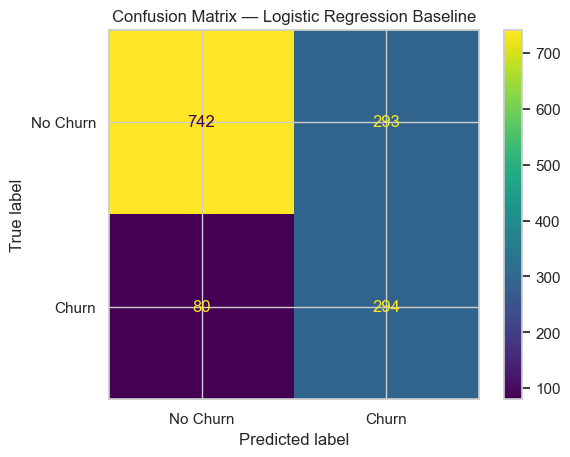

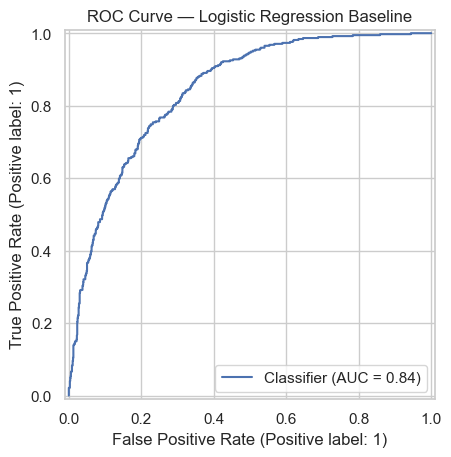

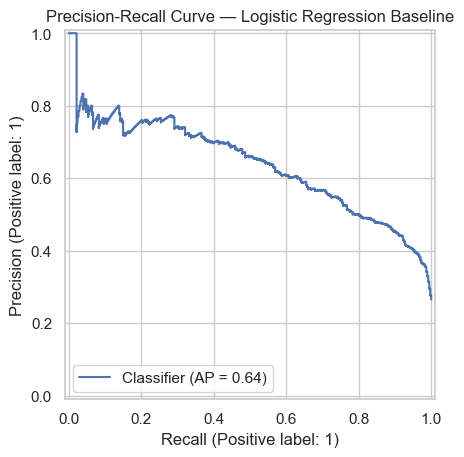

In [29]:
log_reg_pipeline = Pipeline([
    ("preprocess", preprocessor_scaled),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )),
])

log_reg_pipeline.fit(X_train, y_train)

lr_metrics, lr_pred, lr_proba = evaluate_classifier(
    log_reg_pipeline,
    X_test,
    y_test,
    model_name="Logistic Regression Baseline"
)

## 10. Model 2 — Random Forest baseline

===== Random Forest Baseline =====
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.61      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



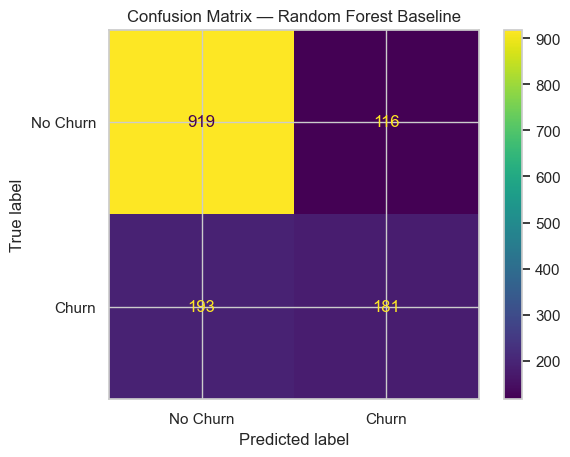

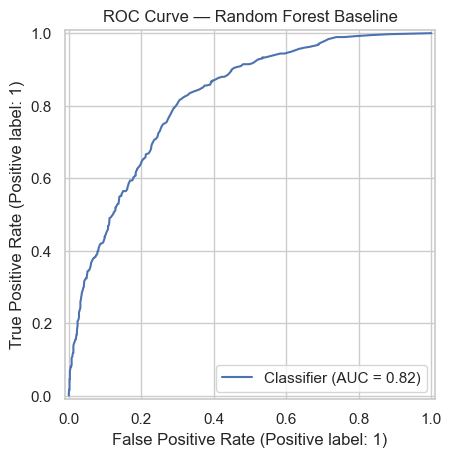

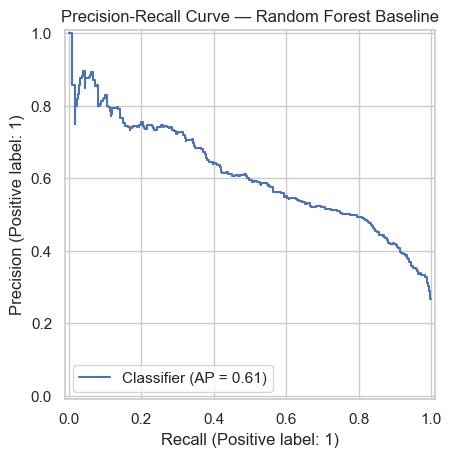

In [30]:
rf_pipeline = Pipeline([
    ("preprocess", preprocessor_no_scale),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    )),
])

rf_pipeline.fit(X_train, y_train)

rf_metrics, rf_pred, rf_proba = evaluate_classifier(
    rf_pipeline,
    X_test,
    y_test,
    model_name="Random Forest Baseline"
)

## 11. Compare baseline models

In [31]:
baseline_results = pd.DataFrame([lr_metrics, rf_metrics])
baseline_results.sort_values(by="recall", ascending=False)

,model,threshold,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression Baseline,0.5,0.735273,0.500852,0.786096,0.611863,0.842649
1,Random Forest Baseline,0.5,0.780696,0.609428,0.483957,0.539493,0.818354


## 12. Hyperparameter tuning

Dùng `GridSearchCV` với `StratifiedKFold`.

Mặc định chọn `SCORING = "recall"` vì churn prediction thường muốn bắt nhiều khách hàng churn.
Có thể đổi thành `"f1"` hoặc `"roc_auc"`.

In [32]:
SCORING = "recall"

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

### 12.1 Tuning Logistic Regression

In [33]:
lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
}

lr_grid = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=lr_param_grid,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("Best Logistic Regression params:")
print(lr_grid.best_params_)
print(f"Best CV {SCORING}: {lr_grid.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Logistic Regression params:
{'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV recall: 0.8428


===== Logistic Regression Tuned =====
              precision    recall  f1-score   support

    No Churn       0.91      0.69      0.79      1035
       Churn       0.49      0.80      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.72      0.74      1409



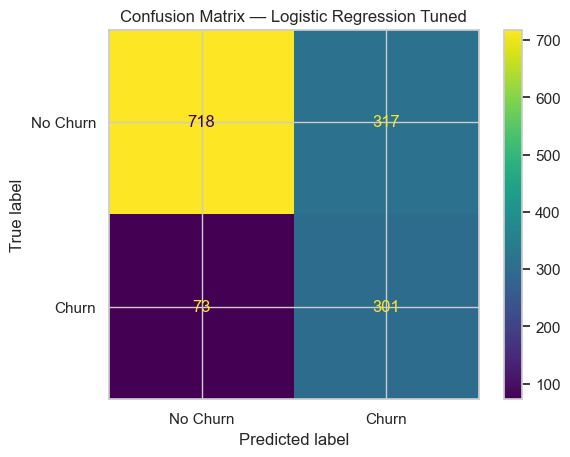

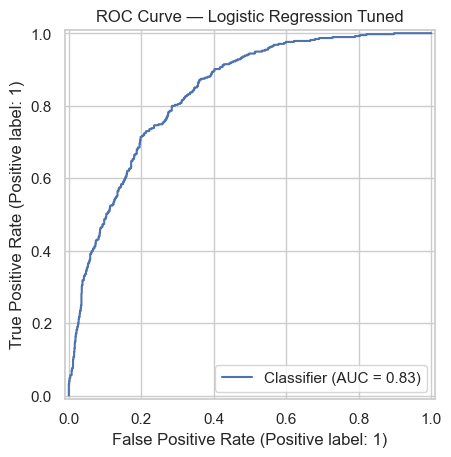

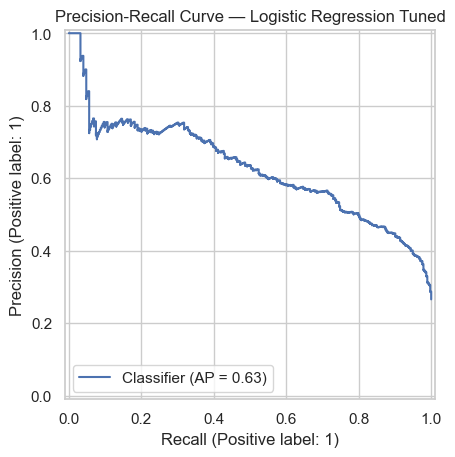

In [34]:
lr_tuned_metrics, lr_tuned_pred, lr_tuned_proba = evaluate_classifier(
    lr_grid.best_estimator_,
    X_test,
    y_test,
    model_name="Logistic Regression Tuned"
)

### 12.2 Tuning Random Forest

In [35]:
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": ["balanced", "balanced_subsample"],
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest params:")
print(rf_grid.best_params_)
print(f"Best CV {SCORING}: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Random Forest params:
{'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV recall: 0.8080


===== Random Forest Tuned =====
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



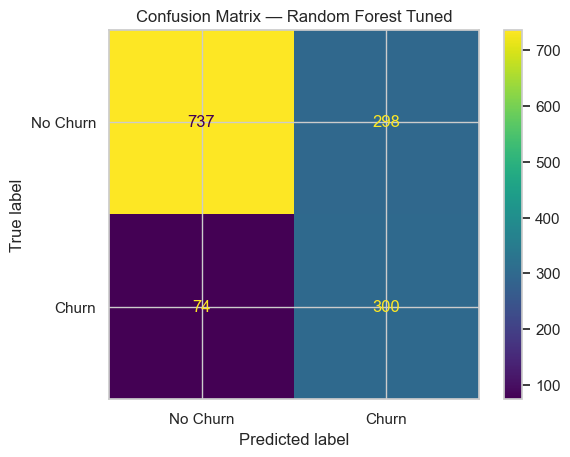

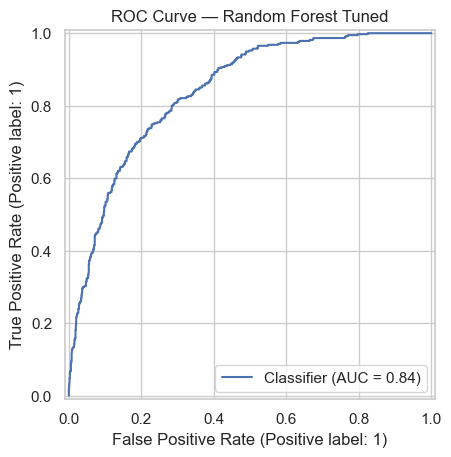

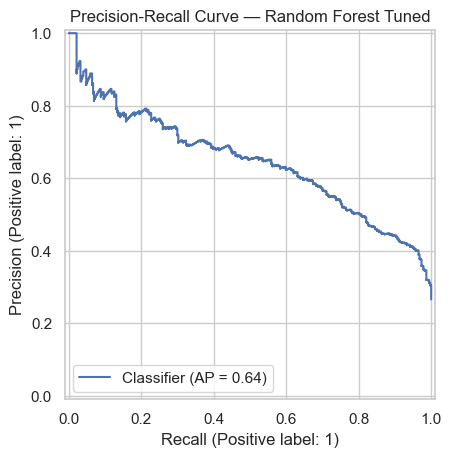

In [36]:
rf_tuned_metrics, rf_tuned_pred, rf_tuned_proba = evaluate_classifier(
    rf_grid.best_estimator_,
    X_test,
    y_test,
    model_name="Random Forest Tuned"
)

## 13. Final comparison

In [37]:
all_results = pd.DataFrame([
    lr_metrics,
    rf_metrics,
    lr_tuned_metrics,
    rf_tuned_metrics,
])

all_results.sort_values(by=SCORING, ascending=False)

,model,threshold,accuracy,precision,recall,f1,roc_auc
2,Logistic Regression Tuned,0.5,0.723208,0.487055,0.804813,0.606855,0.834985
3,Random Forest Tuned,0.5,0.735983,0.501672,0.802139,0.617284,0.840697
0,Logistic Regression Baseline,0.5,0.735273,0.500852,0.786096,0.611863,0.842649
1,Random Forest Baseline,0.5,0.780696,0.609428,0.483957,0.539493,0.818354


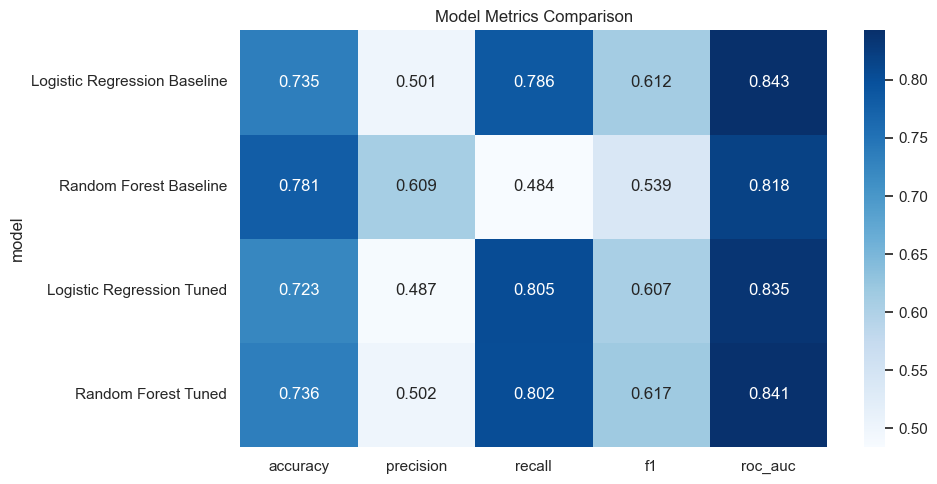

In [38]:
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]

plt.figure(figsize=(10, 5))
sns.heatmap(
    all_results.set_index("model")[metric_cols],
    annot=True,
    fmt=".3f",
    cmap="Blues"
)
plt.title("Model Metrics Comparison")
plt.tight_layout()
plt.show()

## 14. Choose best model

Ta chọn model tốt nhất theo metric đang dùng trong `SCORING`.

In [39]:
candidate_models = {
    "Logistic Regression Baseline": log_reg_pipeline,
    "Random Forest Baseline": rf_pipeline,
    "Logistic Regression Tuned": lr_grid.best_estimator_,
    "Random Forest Tuned": rf_grid.best_estimator_,
}

sort_metric = SCORING if SCORING in ["recall", "f1", "roc_auc"] else "recall"

best_row = all_results.sort_values(by=sort_metric, ascending=False).iloc[0]
best_model_name = best_row["model"]
best_model = candidate_models[best_model_name]

print("Best model:", best_model_name)
print("Selected by:", sort_metric)
display(best_row.to_frame().T)

Best model: Logistic Regression Tuned
Selected by: recall


,model,threshold,accuracy,precision,recall,f1,roc_auc
2,Logistic Regression Tuned,0.5,0.723208,0.487055,0.804813,0.606855,0.834985


## 15. Optional — Adjust threshold

Mặc định threshold = 0.5.  
Nếu muốn tăng recall, có thể thử threshold thấp hơn như 0.4 hoặc 0.3.

In [40]:
thresholds_to_try = [0.3, 0.4, 0.5, 0.6]
threshold_results = []

for th in thresholds_to_try:
    metrics, _, _ = evaluate_classifier(
        best_model,
        X_test,
        y_test,
        model_name=f"{best_model_name} | threshold={th}",
        threshold=th,
        show_plots=False
    )
    threshold_results.append(metrics)

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

===== Logistic Regression Tuned | threshold=0.3 =====
              precision    recall  f1-score   support

    No Churn       0.96      0.49      0.65      1035
       Churn       0.40      0.94      0.56       374

    accuracy                           0.61      1409
   macro avg       0.68      0.72      0.61      1409
weighted avg       0.81      0.61      0.63      1409

===== Logistic Regression Tuned | threshold=0.4 =====
              precision    recall  f1-score   support

    No Churn       0.94      0.59      0.73      1035
       Churn       0.44      0.90      0.59       374

    accuracy                           0.67      1409
   macro avg       0.69      0.75      0.66      1409
weighted avg       0.81      0.67      0.69      1409

===== Logistic Regression Tuned | threshold=0.5 =====
              precision    recall  f1-score   support

    No Churn       0.91      0.69      0.79      1035
       Churn       0.49      0.80      0.61       374

    accuracy        

,model,threshold,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression Tuned | threshold=0.3,0.3,0.613201,0.402509,0.943850,0.564349,0.834985
1,Logistic Regression Tuned | threshold=0.4,0.4,0.674237,0.444005,0.901070,0.594881,0.834985
2,Logistic Regression Tuned | threshold=0.5,0.5,0.723208,0.487055,0.804813,0.606855,0.834985
3,Logistic Regression Tuned | threshold=0.6,0.6,0.765791,0.543651,0.732620,0.624146,0.834985


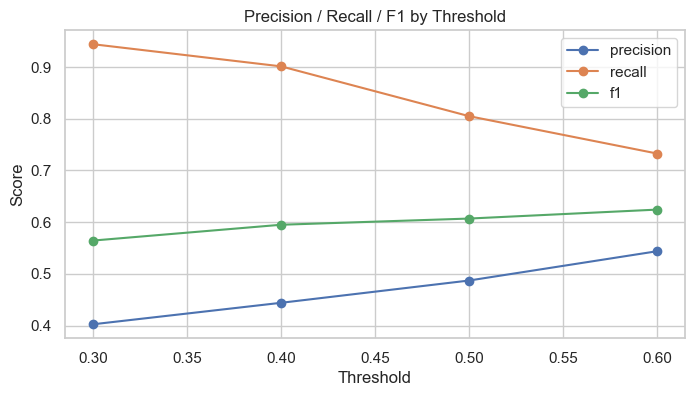

In [41]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_results_df["threshold"], threshold_results_df["precision"], marker="o", label="precision")
plt.plot(threshold_results_df["threshold"], threshold_results_df["recall"], marker="o", label="recall")
plt.plot(threshold_results_df["threshold"], threshold_results_df["f1"], marker="o", label="f1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 by Threshold")
plt.legend()
plt.show()

## 16. Feature importance / interpretation

Với Random Forest: xem `feature_importances_`.  
Với Logistic Regression: xem `coef_`.

Do có One-Hot Encoding, ta cần lấy tên feature sau preprocessing.

,feature,coefficient,abs_coefficient
2,MonthlyCharges,0.691707,0.691707
1,tenure,-0.618788,0.618788
8,is_month_to_month,0.523516,0.523516
18,PhoneService_Yes,-0.306524,0.306524
46,PaperlessBilling_No,-0.194036,0.194036
9,no_online_security,0.168506,0.168506
10,no_tech_support,0.137623,0.137623
50,PaymentMethod_Electronic check,0.069677,0.069677
0,SeniorCitizen,0.050610,0.050610
7,has_multiple_services,0.000000,0.000000


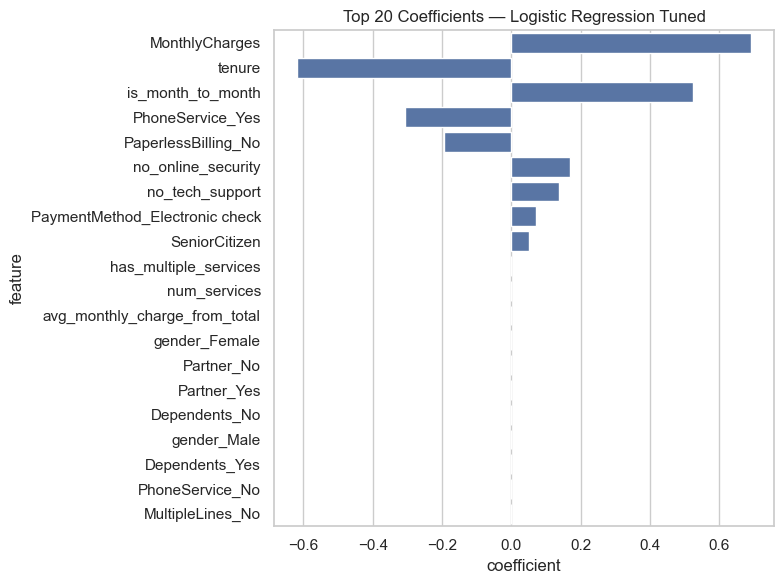

In [42]:
def get_feature_names_from_preprocessor(preprocessor: ColumnTransformer) -> list:
    feature_names = []

    for name, transformer, columns in preprocessor.transformers_:
        if name == "remainder":
            continue

        if hasattr(transformer, "named_steps"):
            final_step = list(transformer.named_steps.values())[-1]
            if hasattr(final_step, "get_feature_names_out"):
                names = final_step.get_feature_names_out(columns)
            else:
                names = columns
        else:
            if hasattr(transformer, "get_feature_names_out"):
                names = transformer.get_feature_names_out(columns)
            else:
                names = columns

        feature_names.extend(list(names))

    return feature_names


best_model.fit(X_train, y_train)

preprocessor = best_model.named_steps["preprocess"]
final_estimator = best_model.named_steps["model"]
feature_names = get_feature_names_from_preprocessor(preprocessor)

if hasattr(final_estimator, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": final_estimator.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(importance_df.head(20))

    plt.figure(figsize=(8, 6))
    sns.barplot(data=importance_df.head(20), x="importance", y="feature")
    plt.title(f"Top 20 Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.show()

elif hasattr(final_estimator, "coef_"):
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": final_estimator.coef_[0],
    })
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

    display(coef_df.head(20))

    plt.figure(figsize=(8, 6))
    sns.barplot(data=coef_df.head(20), x="coefficient", y="feature")
    plt.title(f"Top 20 Coefficients — {best_model_name}")
    plt.tight_layout()
    plt.show()

## 17. Save model

Ta save cả preprocessing + model trong cùng một `Pipeline`.

File output:

```text
artifacts/customer_churn_model_v1.joblib
artifacts/customer_churn_model_v1_info.json
```

In [44]:

MODEL_PATH = BASE_DIR / "models" / "customers" / "customer_churn_model_v1.joblib"
INFO_PATH = BASE_DIR / "models" / "customers" / "customer_churn_model_v1_info.json"

joblib.dump(best_model, MODEL_PATH)

model_info = {
    "project": "Customer Churn Prediction",
    "version": "v1_notebook_only",
    "dataset": "Kaggle Telco Customer Churn",
    "target": TARGET,
    "best_model_name": best_model_name,
    "selected_metric": sort_metric,
    "test_metrics": best_row.to_dict(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "random_state": RANDOM_STATE,
}

with open(INFO_PATH, "w", encoding="utf-8") as f:
    json.dump(model_info, f, indent=4, ensure_ascii=False)

print("Saved model to:", MODEL_PATH)
print("Saved model info to:", INFO_PATH)

Saved model to: c:\Users\ASUS\Documents\PROJECT\intro_to_AI\models\customers\customer_churn_model_v1.joblib
Saved model info to: c:\Users\ASUS\Documents\PROJECT\intro_to_AI\models\customers\customer_churn_model_v1_info.json


## 18. Load model and test prediction

In [45]:
loaded_model = joblib.load(MODEL_PATH)

sample_X = X_test.head(5)
sample_pred = loaded_model.predict(sample_X)
sample_proba = loaded_model.predict_proba(sample_X)[:, 1]

sample_result = sample_X.copy()
sample_result["actual_churn"] = y_test.head(5).values
sample_result["predicted_churn"] = sample_pred
sample_result["churn_probability"] = sample_proba.round(4)

sample_result

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_zero,tenure_group,avg_monthly_charge_from_total,num_services,has_multiple_services,is_month_to_month,no_online_security,no_tech_support,actual_churn,predicted_churn,churn_probability
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,60+,117.613889,8,1,0,0,0,0,0,0.2218
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,0-12,113.568750,5,1,1,1,0,0,1,0.8319
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,25-48,78.321951,6,1,0,0,1,0,0,0.2707
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,13-24,81.597222,3,1,1,1,0,0,1,0.6416
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,60+,82.213194,7,1,0,0,1,0,0,0.1580


## 19. Business interpretation template

Sau khi chạy notebook, điền phần này bằng kết quả thật.

### Model tốt nhất
- Best model: `Logistic Regression Tuned`
- Metric chính: `recall`

### Performance
- Accuracy: `72%`
- Precision: `48,7%`
- Recall: `80,5%`
- F1-score: `0,607`
- ROC-AUC: `0,835`

### Insight từ EDA
- Nhóm khách hàng churn cao: `month-to-month`
- Feature quan trọng: `...`

### Business action
Nếu `churn_probability` cao, công ty có thể:

- Gửi discount/voucher
- Gọi chăm sóc khách hàng
- Đề xuất chuyển sang hợp đồng dài hạn
- Tặng thêm support/security

### Hạn chế Version 1
- Chưa deployment
- Chưa dashboard
- Chưa thử XGBoost/LightGBM
- Chưa tối ưu threshold theo cost thật

## 20. Checklist Version 1

- [ ] Tải dataset từ Kaggle
- [ ] Load data
- [ ] EDA
- [ ] Missing values
- [ ] Feature engineering
- [ ] Train/test split
- [ ] Logistic Regression
- [ ] Random Forest
- [ ] Evaluation
- [ ] Hyperparameter tuning
- [ ] Choose best model
- [ ] Save model bằng joblib
- [ ] Load model và predict thử